# Generador de transacciones sintéticas — Proyecto 1

Genera la base de transacciones de tarjetahabientes del Banco del Altiplano que se usa en todo
el proyecto (Modelo A, Modelo B y la apuesta C). Es reproducible: la misma semilla produce
siempre el mismo dataset (se valida más abajo).

**Qué construye, en orden:**
1. Un perfil de comportamiento por cliente (frecuencia de uso, monto típico, comercios y canal
   preferidos).
2. Transacciones legítimas a partir de ese perfil.
3. Tres tipos de fraude, inyectados como episodios cortos sobre la línea de tiempo de un
   cliente.
4. El dataset final, ordenado cronológicamente, guardado en `data/transacciones.parquet`.

**Decisión de escala:** con 8 000 clientes y 180 días, una frecuencia realista de uso de tarjeta
(~10-15 transacciones al mes) ya genera cientos de miles de filas. Se eligió una tasa que deja
el dataset en ~430 000 transacciones legítimas, para que el modelo secuencial entrene en
minutos y no en horas, dado el plazo de entrega.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

# --- tamaño de la simulación ---
N_CLIENTS = 8000
N_DAY = 180
N_CATEGORIES = 25
SECONDS_PER_DAY = 86400
CATEGORIES_ALTO_RIESGO = np.array([20, 21, 22, 23, 24])
CANALES = np.array(["presencial", "online", "cajero"])
FECHA_INICIO = pd.Timestamp("2026-01-05")

# --- fraude ---
N_EPISODIOS_POR_TIPO = 400     # episodios por cada uno de los 3 tipos (~1.2% de tasa de fraude)
DIA_MIN_EPISODIO = 5           # deja margen para que el cliente ya tenga historia previa
DIA_MAX_EPISODIO = N_DAY - 3   # deja margen para que el episodio no se corte al final del horizonte
PROP_SONDEO_LENTO = 0.20       # fracción de "sondeo y fuga" generada como caso difícil (ver abajo)

pd.set_option("display.max_columns", None)


## Tipos de fraude

Se eligieron tres patrones. El primero depende del **orden** de las transacciones: la misma
canasta de eventos, en otro orden, no se ve igual de sospechosa. Los otros dos son más
detectables por variables agregadas — sirven de contraste para que la comparación A vs. B tenga
sentido.

### 1. Sondeo y fuga (`sondeo_y_fuga`) — depende del orden
Entre 3 y 6 compras muy pequeñas (Q5–Q40, distintos comercios, siempre por canal en línea) en
pocos minutos, seguidas de **una** compra grande (varias veces el monto típico del cliente). Es
el patrón que describe el propio enunciado: el atacante prueba que la tarjeta funciona antes de
vaciarla. Si se baraja el orden, el monto máximo del día sigue siendo el mismo, pero la
secuencia "pequeñas → grande" desaparece.

**Caso difícil documentado** (20&nbsp;% de los episodios de este tipo, marcado
`variante_dificil=True`): una versión "lenta", con horas — no minutos — entre transacciones, y
una compra final de solo 3–6 veces el monto típico (no 8–20 veces). Se espera que el Modelo A la
pase por alto porque no altera las variables por hora, y que incluso el Modelo B tenga más
dificultad, porque el salto de monto es menos extremo y la ventana es más ancha que la de un
sondeo típico.

### 2. Ráfaga en categorías de alto riesgo (`rafaga_alto_riesgo`)
Entre 2 y 5 transacciones de monto alto concentradas en las categorías 20–24 (ya marcadas como
de alto riesgo en el motor actual), en un lapso de hasta una hora. No depende tanto del orden:
cada transacción individual ya es sospechosa por monto y categoría, así que un buen Modelo A
también debería detectarla.

### 3. Toma de cuenta con salto de canal (`salto_de_canal`)
El cliente tiene un canal habitual (presencial, en línea o cajero). El episodio inserta entre 3
y 6 transacciones de monto moderado por un canal **distinto** al habitual, en un lapso de una a
pocas horas — el patrón típico de una cuenta comprometida que empieza a usarse desde otro canal.

Cada episodio queda identificado con `id_episodio_fraude` (para poder evaluarlo como grupo más
adelante) y las columnas `tipo_fraude` y `variante_dificil` documentan qué generó cada fila.
**Ninguna de las dos se debe usar como variable de entrada de los modelos** — existen solo para
análisis y para las pruebas de falsificación.


In [2]:
def _tiempo_absoluto(dia_offset, seg_del_dia):
    return dia_offset * SECONDS_PER_DAY + seg_del_dia


def _desde_tiempo_absoluto(t_abs):
    dia_offset = t_abs // SECONDS_PER_DAY
    seg_del_dia = t_abs % SECONDS_PER_DAY
    return dia_offset, seg_del_dia


def _fila_fraude(id_cliente, dia_offset, seg_del_dia, monto, categoria, canal,
                  tipo_fraude, id_episodio, dificil):
    return dict(
        id_cliente=id_cliente, dia_offset=dia_offset, seg_del_dia=seg_del_dia,
        monto=monto, categoria_comercio=categoria, canal=canal,
        es_fraude=1, tipo_fraude=tipo_fraude, id_episodio_fraude=id_episodio,
        variante_dificil=dificil,
    )


def generar_transacciones(seed):
    """Genera el dataset completo (legítimas + fraude) para una semilla dada.

    Reproducible: la misma semilla siempre produce el mismo DataFrame, fila por fila
    (se valida en la siguiente sección). Todo el estado aleatorio vive en el `rng`
    local, así que dos llamadas con la misma semilla no interfieren entre sí.
    """
    rng = np.random.default_rng(seed)

    # ---- 1. perfil por cliente ------------------------------------------------
    tasa_diaria = rng.gamma(shape=2.0, scale=0.15, size=N_CLIENTS)     # ~0.3 tx/día en promedio
    mu_monto = rng.normal(loc=np.log(150), scale=0.4, size=N_CLIENTS)  # mediana de monto ~Q150
    sigma_monto = rng.uniform(0.4, 0.9, size=N_CLIENTS)
    home_categorias = rng.integers(0, N_CATEGORIES, size=(N_CLIENTS, 3))
    canal_home_idx = rng.choice(3, size=N_CLIENTS, p=[0.55, 0.30, 0.15])

    # ---- 2. transacciones legítimas (proceso de Poisson homogéneo por cliente) -
    conteos = rng.poisson(lam=tasa_diaria * N_DAY)
    id_cliente_legit = np.repeat(np.arange(N_CLIENTS), conteos)
    n_legit = id_cliente_legit.size

    dia_offset = rng.uniform(0, N_DAY, size=n_legit)
    hora = np.clip(rng.normal(13, 4, size=n_legit), 0, 23.999)         # actividad concentrada de día
    seg_del_dia = hora * 3600 + rng.integers(0, 60, size=n_legit) * 60

    mu_i = mu_monto[id_cliente_legit]
    sigma_i = sigma_monto[id_cliente_legit]
    monto = np.maximum(5.0, rng.lognormal(mean=mu_i, sigma=sigma_i))

    es_home_cat = rng.random(n_legit) < 0.85
    idx_home = rng.integers(0, 3, size=n_legit)
    categoria = np.where(es_home_cat, home_categorias[id_cliente_legit, idx_home],
                          rng.integers(0, N_CATEGORIES, size=n_legit))

    es_home_canal = rng.random(n_legit) < 0.90
    canal_idx = np.where(es_home_canal, canal_home_idx[id_cliente_legit],
                          rng.integers(0, 3, size=n_legit))

    legit = pd.DataFrame({
        "id_cliente": id_cliente_legit, "dia_offset": dia_offset, "seg_del_dia": seg_del_dia,
        "monto": monto, "categoria_comercio": categoria, "canal": CANALES[canal_idx],
        "es_fraude": 0, "tipo_fraude": "ninguno", "id_episodio_fraude": -1,
        "variante_dificil": False,
    })

    # ---- 3. episodios de fraude ------------------------------------------------
    filas_fraude = []
    id_episodio = 0

    # -- tipo 1: sondeo y fuga (depende del orden) --
    for _ in range(N_EPISODIOS_POR_TIPO):
        cliente = rng.integers(0, N_CLIENTS)
        t = _tiempo_absoluto(rng.uniform(DIA_MIN_EPISODIO, DIA_MAX_EPISODIO),
                              rng.uniform(0, SECONDS_PER_DAY))
        lento = rng.random() < PROP_SONDEO_LENTO
        tipico = np.exp(mu_monto[cliente])

        for j in range(rng.integers(3, 7)):
            if j > 0:
                t += rng.uniform(2 * 3600, 8 * 3600) if lento else rng.uniform(2 * 60, 15 * 60)
            dia_j, seg_j = _desde_tiempo_absoluto(t)
            filas_fraude.append(_fila_fraude(
                cliente, dia_j, seg_j, rng.uniform(5, 40), rng.integers(0, N_CATEGORIES),
                "online", "sondeo_y_fuga", id_episodio, lento))

        t += rng.uniform(3600, 6 * 3600) if lento else rng.uniform(5 * 60, 30 * 60)
        factor = rng.uniform(3, 6) if lento else rng.uniform(8, 20)
        piso_absoluto = 0 if lento else rng.uniform(1200, 6000)
        dia_g, seg_g = _desde_tiempo_absoluto(t)
        filas_fraude.append(_fila_fraude(
            cliente, dia_g, seg_g, max(tipico * factor, piso_absoluto),
            rng.integers(0, N_CATEGORIES), "online", "sondeo_y_fuga", id_episodio, lento))
        id_episodio += 1

    # -- tipo 2: ráfaga en categorías de alto riesgo --
    for _ in range(N_EPISODIOS_POR_TIPO):
        cliente = rng.integers(0, N_CLIENTS)
        t = _tiempo_absoluto(rng.uniform(DIA_MIN_EPISODIO, DIA_MAX_EPISODIO),
                              rng.uniform(0, SECONDS_PER_DAY))
        tipico = np.exp(mu_monto[cliente])

        for j in range(rng.integers(2, 6)):
            if j > 0:
                t += rng.uniform(5 * 60, 60 * 60)
            canal_j = CANALES[canal_home_idx[cliente]] if rng.random() < 0.5 else rng.choice(CANALES)
            dia_j, seg_j = _desde_tiempo_absoluto(t)
            filas_fraude.append(_fila_fraude(
                cliente, dia_j, seg_j, max(tipico * rng.uniform(2, 6), rng.uniform(300, 4000)),
                rng.choice(CATEGORIES_ALTO_RIESGO), canal_j,
                "rafaga_alto_riesgo", id_episodio, False))
        id_episodio += 1

    # -- tipo 3: toma de cuenta con salto de canal --
    for _ in range(N_EPISODIOS_POR_TIPO):
        cliente = rng.integers(0, N_CLIENTS)
        t = _tiempo_absoluto(rng.uniform(DIA_MIN_EPISODIO, DIA_MAX_EPISODIO),
                              rng.uniform(0, SECONDS_PER_DAY))
        tipico = np.exp(mu_monto[cliente])
        canales_otros = [c for c in range(3) if c != canal_home_idx[cliente]]

        for j in range(rng.integers(3, 7)):
            if j > 0:
                t += rng.uniform(10 * 60, 90 * 60)
            dia_j, seg_j = _desde_tiempo_absoluto(t)
            filas_fraude.append(_fila_fraude(
                cliente, dia_j, seg_j, max(tipico * rng.uniform(1.5, 4), rng.uniform(100, 2500)),
                rng.integers(0, N_CATEGORIES), CANALES[rng.choice(canales_otros)],
                "salto_de_canal", id_episodio, False))
        id_episodio += 1

    fraude = pd.DataFrame(filas_fraude)
    fraude = fraude[(fraude["dia_offset"] >= 0) & (fraude["dia_offset"] < N_DAY)]  # descarta lo que se sale del horizonte

    # ---- 4. combinar, ordenar por tiempo y asignar id --------------------------
    transacciones = pd.concat([legit, fraude], ignore_index=True)
    transacciones["marca_tiempo"] = FECHA_INICIO + pd.to_timedelta(
        transacciones["dia_offset"] * SECONDS_PER_DAY + transacciones["seg_del_dia"], unit="s")
    transacciones = transacciones.sort_values("marca_tiempo").reset_index(drop=True)
    transacciones.insert(0, "id_transaccion", np.arange(len(transacciones)))
    transacciones = transacciones.drop(columns=["dia_offset", "seg_del_dia"])
    transacciones["canal"] = transacciones["canal"].astype("category")
    transacciones["tipo_fraude"] = transacciones["tipo_fraude"].astype("category")

    return transacciones


In [3]:
transacciones = generar_transacciones(SEED)

print(f"Filas: {len(transacciones):,}")
print(f"Clientes con al menos una transacción: {transacciones['id_cliente'].nunique():,}")
print(f"Tasa de fraude: {transacciones['es_fraude'].mean() * 100:.3f}%")
print(f"Rango de fechas: {transacciones['marca_tiempo'].min()} -> {transacciones['marca_tiempo'].max()}")
transacciones.head()


Filas: 436,931
Clientes con al menos una transacción: 7,992
Tasa de fraude: 1.239%
Rango de fechas: 2026-01-05 04:36:32.657952564 -> 2026-07-04 22:38:00.317451974


,id_transaccion,id_cliente,monto,categoria_comercio,canal,es_fraude,tipo_fraude,id_episodio_fraude,variante_dificil,marca_tiempo
0,0,2871,195.820980,5,online,0,ninguno,-1,False,2026-01-05 04:36:32.657952564
1,1,5888,182.419552,5,presencial,0,ninguno,-1,False,2026-01-05 05:12:34.106325645
2,2,1347,59.363534,15,presencial,0,ninguno,-1,False,2026-01-05 05:55:52.035109993
3,3,7869,62.109789,13,presencial,0,ninguno,-1,False,2026-01-05 05:56:46.340102608
4,4,2972,395.293972,17,presencial,0,ninguno,-1,False,2026-01-05 07:46:18.784632879


## Validación de reproducibilidad

El enunciado exige que el generador produzca los mismos datos con la misma semilla. Se valida
de dos formas: (a) dos corridas con `SEED=42` deben coincidir fila por fila, y (b) una semilla
distinta debe producir un dataset distinto — confirma que `SEED` realmente controla la
aleatoriedad y no hay una fuga de estado global entre corridas.


In [4]:
# (a) misma semilla -> mismo dataset, fila por fila
repeticion = generar_transacciones(SEED)
assert transacciones.equals(repeticion), "El generador no es reproducible con la misma semilla"
print("OK: dos corridas con SEED=42 producen exactamente el mismo dataset.")

# (b) otra semilla -> otro dataset
distinto = generar_transacciones(SEED + 1)
assert not transacciones.equals(distinto)
print("OK: cambiar la semilla sí cambia el dataset generado.")

del repeticion, distinto


OK: dos corridas con SEED=42 producen exactamente el mismo dataset.


OK: cambiar la semilla sí cambia el dataset generado.


## Revisión rápida de calidad

Antes de guardar, un vistazo a que los tres tipos de fraude quedaron representados, a que los
montos de fraude sí se distinguen de los legítimos (sin ser triviales de separar) y a que el
volumen semanal de fraude no tiene huecos ni picos artificiales por construcción.


tipo_fraude
ninguno               431517
sondeo_y_fuga           2230
salto_de_canal          1804
rafaga_alto_riesgo      1380
Name: count, dtype: int64

                       count         mean          50%           max
tipo_fraude                                                         
ninguno             431517.0   206.231815   151.870252  12749.574585
rafaga_alto_riesgo    1380.0  2200.415703  2096.850770   3988.916034
salto_de_canal        1804.0  1338.126124  1323.048617   2499.198680
sondeo_y_fuga         2230.0   564.960129    26.938995   6534.201786


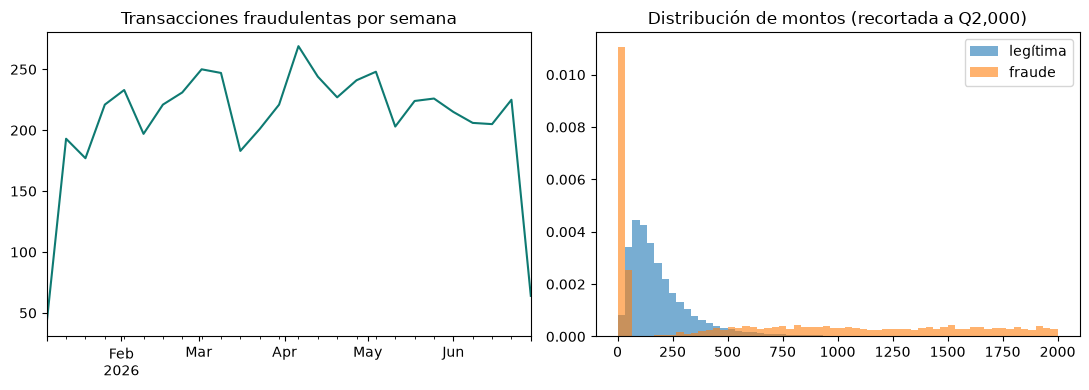

In [5]:
print(transacciones["tipo_fraude"].value_counts())
print()
print(transacciones.groupby("tipo_fraude", observed=True)["monto"].describe()[["count", "mean", "50%", "max"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

transacciones.set_index("marca_tiempo")["es_fraude"].resample("7D").sum().plot(
    ax=axes[0], color="#0e7a72")
axes[0].set_title("Transacciones fraudulentas por semana")
axes[0].set_xlabel("")

axes[1].hist(transacciones.loc[transacciones["es_fraude"] == 0, "monto"], bins=60,
             range=(0, 2000), alpha=0.6, label="legítima", density=True)
axes[1].hist(transacciones.loc[transacciones["es_fraude"] == 1, "monto"], bins=60,
             range=(0, 2000), alpha=0.6, label="fraude", density=True)
axes[1].set_title("Distribución de montos (recortada a Q2,000)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Guardar el dataset

Se guarda completo, sin particionar — la partición temporal (train/val/test) es responsabilidad
del siguiente notebook (`linea_base.ipynb`), para que quede en un solo lugar y ambos modelos la
usen idéntica.


In [6]:
import os

os.makedirs("data", exist_ok=True)
transacciones.to_parquet("data/transacciones.parquet", index=False)
print("Guardado en data/transacciones.parquet")
print(transacciones.dtypes)


Guardado en data/transacciones.parquet
id_transaccion                 int64
id_cliente                     int64
monto                        float64
categoria_comercio             int64
canal                       category
es_fraude                      int64
tipo_fraude                 category
id_episodio_fraude             int64
variante_dificil                bool
marca_tiempo          datetime64[ns]
dtype: object


## Diccionario de columnas

| Columna | Significado |
|---|---|
| `id_transaccion` | identificador único, asignado en orden cronológico global |
| `id_cliente` | identificador del cliente/tarjeta (0–7999) |
| `marca_tiempo` | fecha y hora de la transacción — es el orden que usa el Modelo B |
| `monto` | monto en quetzales |
| `categoria_comercio` | categoría del comercio (0–24; 20–24 son las de alto riesgo) |
| `canal` | `presencial`, `online` o `cajero` |
| `es_fraude` | **etiqueta**: 1 si la transacción es parte de un episodio de fraude |
| `tipo_fraude` | `sondeo_y_fuga`, `rafaga_alto_riesgo`, `salto_de_canal` o `ninguno` — **no usar como variable de entrada**, solo sirve para análisis y para la prueba "evaluar por mecanismo de fraude" |
| `id_episodio_fraude` | agrupa las filas de un mismo episodio de fraude (-1 si es legítima) — **no usar como variable de entrada** |
| `variante_dificil` | `True` en la versión "lenta" de `sondeo_y_fuga`, el caso que se documentó como el que más le costará al modelo |

**Secuencia de un cliente** = todas sus filas ordenadas por `marca_tiempo`. Cada secuencia puede
mezclar transacciones legítimas y, si ese cliente fue elegido para un episodio, unas pocas
fraudulentas intercaladas — igual que en la vida real.

**Siguiente paso:** `linea_base.ipynb` carga este parquet, hace la partición temporal, construye
las variables agregadas, entrena el Modelo A y define la función de evaluación común que se
reutiliza para el Modelo B.
